# Per-site (individual garden) new peaks — SV-only vs SNP, garden by garden

Each of the 31 GrENE-Net gardens has its own single-site LOCO-EMMAX founder scan (rank-normalised
selection coefficient `s`, kinship-corrected, genomic-control calibrated) on 212 founders. This is
the **per-garden** lens on the SV-only layer: the multi-trait (JOINT) meta finds indels/SVs
*redundant* with SNPs (garden-specific peaks dilute across a 30-df meta and average to ~0), but
per garden they surface real peaks the SNP scan misses.

**Blocks = production clq0.9 TILING** (`blocks_tiling.merge_small_blocks(assign_tiling(...))`,
full genome coverage — same partition as the production WZA `wza_in_clq09_tile`). The earlier
version of this notebook used the non-tiling BigLD LD-islands, which dropped ~28% of variants
in inter-block gaps; that is fixed here.

A "**significant SV-only block**" in a garden = the block's lead (min-p) sv record clears the
per-block Bonferroni (0.05 / n_blocks) in that garden's scan. We keep **every** such block and
mark each (gene, garden) cell by whether the co-located SNP lead is *also* Bonferroni-significant:
**black-edged / solid = non-SNP-only** (SNP-blind, the novel peaks), **white-edged / faded = SNP
also significant** (shown for context, not filtered away). Genes classified with the TAIR-GO +
UniProt annotator. No chart titles (repo convention).

In [1]:
import os, sys
import numpy as np, pandas as pd
from scipy import stats
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.lines as mlines
os.chdir("/global/scratch/projects/fc_moilab/tbellg/kmate")
sys.path.insert(0, "analysis/grenenet_selection")
import lib, blocks_tiling as bt
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
DIR = "analysis/grenenet_selection/varexp"
CLS = "sv"
CHROM_ORDER = ["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"]

def load(name):
    d = np.load(f"{DIR}/class_gwas_{name}.npz", allow_pickle=True)
    chrom = np.array([c.replace("chr", "Chr") for c in d["chrom"]])
    pos = d["pos"].astype(np.int64)
    blk = bt.merge_small_blocks(bt.assign_tiling(chrom, pos, r2=0.9))   # TILING (full coverage)
    return dict(chrom=chrom, pos=pos, Z=d["Z"], sites=[int(s) for s in d["sites"]], blk=blk)

SNP = load("snp"); CL = load(CLS)     # SNP tiling-assign is the slow step (~1 min)
sites = SNP["sites"]
GENES = lib.load_genes()

# gardens ordered & coloured cold -> hot by bio1
bio1 = lib.load_climate().reindex(sites)["bio1"].astype(float)
site_bio1 = {int(s): float(bio1.loc[s]) for s in sites}
site_order = sorted(sites, key=lambda s: site_bio1[s])
xpos = {s: i for i, s in enumerate(site_order)}
BIO_CMAP = plt.cm.coolwarm
BNORM = mpl.colors.Normalize(min(site_bio1.values()), max(site_bio1.values()))
def bio_color(s): return BIO_CMAP(BNORM(site_bio1[s]))

# data-driven span of each merged tiling block (from the class variant positions actually in it)
# -> genes overlapping the REAL merged footprint (avoids the un-merged-span mis-attribution)
_cl = pd.DataFrame({"block": CL["blk"], "chrom": CL["chrom"], "pos": CL["pos"]})
SPAN = _cl[_cl.block != ""].groupby("block").agg(chrom=("chrom", "first"),
                                                 start=("pos", "min"), end=("pos", "max"))
def genes_on(block):
    if block not in SPAN.index: return []
    s = SPAN.loc[block]
    gc = GENES[(GENES.chrom == s.chrom) & (GENES.end >= s.start) & (GENES.start <= s.end)]
    return list(gc.gene)

def nlp(D, si):
    return -np.log10(np.clip(2 * stats.norm.sf(np.abs(D["Z"][:, si])), 1e-300, 1))

def site_leads(D, si):
    df = pd.DataFrame({"block": D["blk"], "chrom": D["chrom"], "pos": D["pos"], "nlp": nlp(D, si)})
    df = df[df.block != ""]
    lead = df.loc[df.groupby("block")["nlp"].idxmax()].reset_index(drop=True)
    p = 10.0 ** (-lead["nlp"].to_numpy())
    lead["fdr"] = lib.bh(p) < 0.05
    lead["bonf"] = p < 0.05 / len(p)
    return lead

print(f"{len(sites)} gardens; SNP {len(SNP['pos']):,} / {CLS} {len(CL['pos']):,} records; "
      f"tiling blocks SNP {len(set(SNP['blk'])):,} / {CLS} {len(set(CL['blk'])):,}")

30 gardens; SNP 1,752,846 / sv 12,789 records; tiling blocks SNP 57,504 / sv 2,623


In [2]:
# --- variant size (bp) per position, from the SAME panel meta the npz was built from ---
# |alt_len - ref_len|; multiallelic positions collapse to the MAX (largest variant at the locus).
# Every npz (chrom,pos) is present in this meta (verified), so every lead gets a real size.
_size = {}
for _ci in range(1, 6):
    _m = np.load(f"{lib.PROJ}/panel/arch3/chr{_ci}/var_pa_231_arch3_chr{_ci}.meta.npz", allow_pickle=True)
    _p = _m["pos"].astype(np.int64)
    _s = np.abs(_m["alt_len"].astype(int) - _m["ref_len"].astype(int))
    _mx = pd.DataFrame({"pos": _p, "sz": _s}).groupby("pos")["sz"].max()
    _size.update({(f"Chr{_ci}", int(pp)): int(ss) for pp, ss in _mx.items()})
def var_size(chrom, pos): return _size.get((chrom, int(pos)), 0)
print(f"size map: {len(_size):,} positions")

size map: 7,496,027 positions


## Significant blocks across gardens (all class-Bonferroni blocks, SNP-status flagged)

For every garden, take the class lead per block and the SNP lead per block; keep every block the
class scan calls Bonferroni-significant, and flag `snp_sig` = the SNP lead in that same block is
also Bonferroni-significant. `non-SNP-only` cells (`~snp_sig`) are the SNP-blind / novel peaks.

In [3]:
recs = []
for si, sid in enumerate(sites):
    snp = (site_leads(SNP, si)[["block", "nlp", "fdr", "bonf"]]
           .rename(columns={"nlp": "snp_nlp", "fdr": "snp_fdr", "bonf": "snp_bonf"}))
    cl = site_leads(CL, si).merge(snp, on="block", how="left")
    cl["snp_nlp"] = cl["snp_nlp"].fillna(0.0)
    cl[["snp_fdr", "snp_bonf"]] = cl[["snp_fdr", "snp_bonf"]].fillna(False)
    sig = cl[cl.bonf].copy()                       # class Bonferroni-significant blocks, this garden
    sig["site"] = int(sid)
    sig["snp_sig"] = sig["snp_bonf"]
    recs.append(sig[["site", "block", "chrom", "pos", "nlp", "snp_nlp", "snp_sig", "fdr", "snp_fdr"]])
ALLPK = pd.concat(recs, ignore_index=True)
ALLPK["genes"] = ALLPK["block"].map(lambda b: ";".join(genes_on(b)))
n_only = int((~ALLPK.snp_sig).sum())
print(f"{len(ALLPK)} (block,garden) class-Bonferroni significant  |  "
      f"non-SNP-only {n_only}  |  SNP-also {len(ALLPK) - n_only}  |  "
      f"{ALLPK.block.nunique()} distinct blocks over {ALLPK.site.nunique()} gardens")

47 (block,garden) class-Bonferroni significant  |  non-SNP-only 45  |  SNP-also 2  |  24 distinct blocks over 24 gardens


In [4]:
# gene-level: one row per (gene, garden), plus a representative (strongest) row per gene
GENE = ALLPK.assign(gene=ALLPK["genes"].str.split(";")).explode("gene")
GENE = GENE[GENE["gene"].astype(bool)].copy()
GA = GENE.sort_values("nlp", ascending=False).drop_duplicates(["gene", "site"])   # 1 row / (gene,garden)
nsite = GA.groupby("gene")["site"].nunique().rename("n_sites")
nsite_only = GA[~GA["snp_sig"]].groupby("gene")["site"].nunique().rename("n_sites_nonsnp_only")
rep = (GA.sort_values("nlp", ascending=False).drop_duplicates("gene")            # strongest garden / gene
         .set_index("gene").join(nsite).join(nsite_only))
rep["n_sites_nonsnp_only"] = rep["n_sites_nonsnp_only"].fillna(0).astype(int)
print(f"{rep.shape[0]} gene-bearing significant genes "
      f"({int((rep.n_sites_nonsnp_only > 0).sum())} non-SNP-only in >=1 garden); "
      f"top recurrence: {rep.n_sites.max()} gardens")

352 gene-bearing significant genes (352 non-SNP-only in >=1 garden); top recurrence: 14 gardens


## Functional classification — TAIR GO + UniProt annotator

`annotate_genes_tair_uniprot.py` (protein name + curated FUNCTION + UniProt keywords + TAIR GO),
the mandated annotator — better category coverage than the mygene-only one. Needs outbound HTTPS.

In [5]:
import importlib.util as _ilu
_annp = "analysis/grenenet_selection/r2_gea_nonsnp/phase1_replication/annotate_genes_tair_uniprot.py"
_sp = _ilu.spec_from_file_location("ann_tu", _annp)
ann_tu = _ilu.module_from_spec(_sp); _sp.loader.exec_module(ann_tu)

A = ann_tu.annotate(sorted(rep.index.tolist())).set_index("gene")
rep = rep.join(A[["symbol", "protein_name", "categories"]])
rep["categories"] = rep["categories"].fillna("")
rep["symbol"] = rep["symbol"].fillna("")
rep["size"] = [var_size(c, p) for c, p in zip(rep["chrom"], rep["pos"])]   # |indel/SV| bp at the lead
_outp = f"{DIR}/persite_new_peaks_{CLS}_genes.csv"
rep.reset_index().to_csv(_outp, index=False)
print(f"wrote {_outp}  ({rep.shape[0]} genes)")
print("category counts (a gene can carry several):")
print(rep["categories"].str.split(",").explode().replace("", pd.NA).dropna().value_counts().to_string())

annotating 352 genes

-- TAIR GAF (GO Consortium) --


GAF cache: /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_selection/r2_gea_nonsnp/phase1_replication/results/cache/tair.gaf.gz (7.2 MB)


   GO for 284/352 genes
-- UniProt REST pass 1: reviewed / Swiss-Prot (taxid 3702) --


  uniprot 40/352 -> 23 mapped


  uniprot 80/352 -> 44 mapped


...

  uniprot 80/137 -> 74 mapped


  uniprot 120/137 -> 111 mapped


  uniprot 137/137 -> 128 mapped


   UniProt total: 343/352 genes
-- mygene.info (kept for GO term NAMES + entrez) --


wrote analysis/grenenet_selection/varexp/persite_new_peaks_sv_genes.csv  (352 genes)
category counts (a gene can carry several):
categories
defense        58
temperature    28
water          24
calcium        19
light          16
oxidative      16
flowering      10


## 1. Dot grid — genes × gardens (cold→hot), colour = category

Reference `newpeak_dotgrid_lfmm_*` style, gardens as columns. **Dot colour** = functional
category, **dot size** ∝ −log10p (sv lead in that garden). **Black-edged / solid** = non-SNP-only
(SNP-blind); **white-edged / faded** = SNP also significant in that block. **Right bar = |indel/SV|
size (bp)** of the gene's lead variant (log scale), the same size axis as the reference
`newpeak_dotgrid_lfmm_*`; rows ordered by that size (largest at top). Size is `|alt_len − ref_len|`
from the panel meta the scan was built from (multiallelic positions take the largest variant). Only
genes recurring on ≥ a threshold number of gardens are drawn (others stay in the CSV). Gardens run
cold→hot left→right by bio1.

/tmp/ipykernel_3998262/3883482155.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


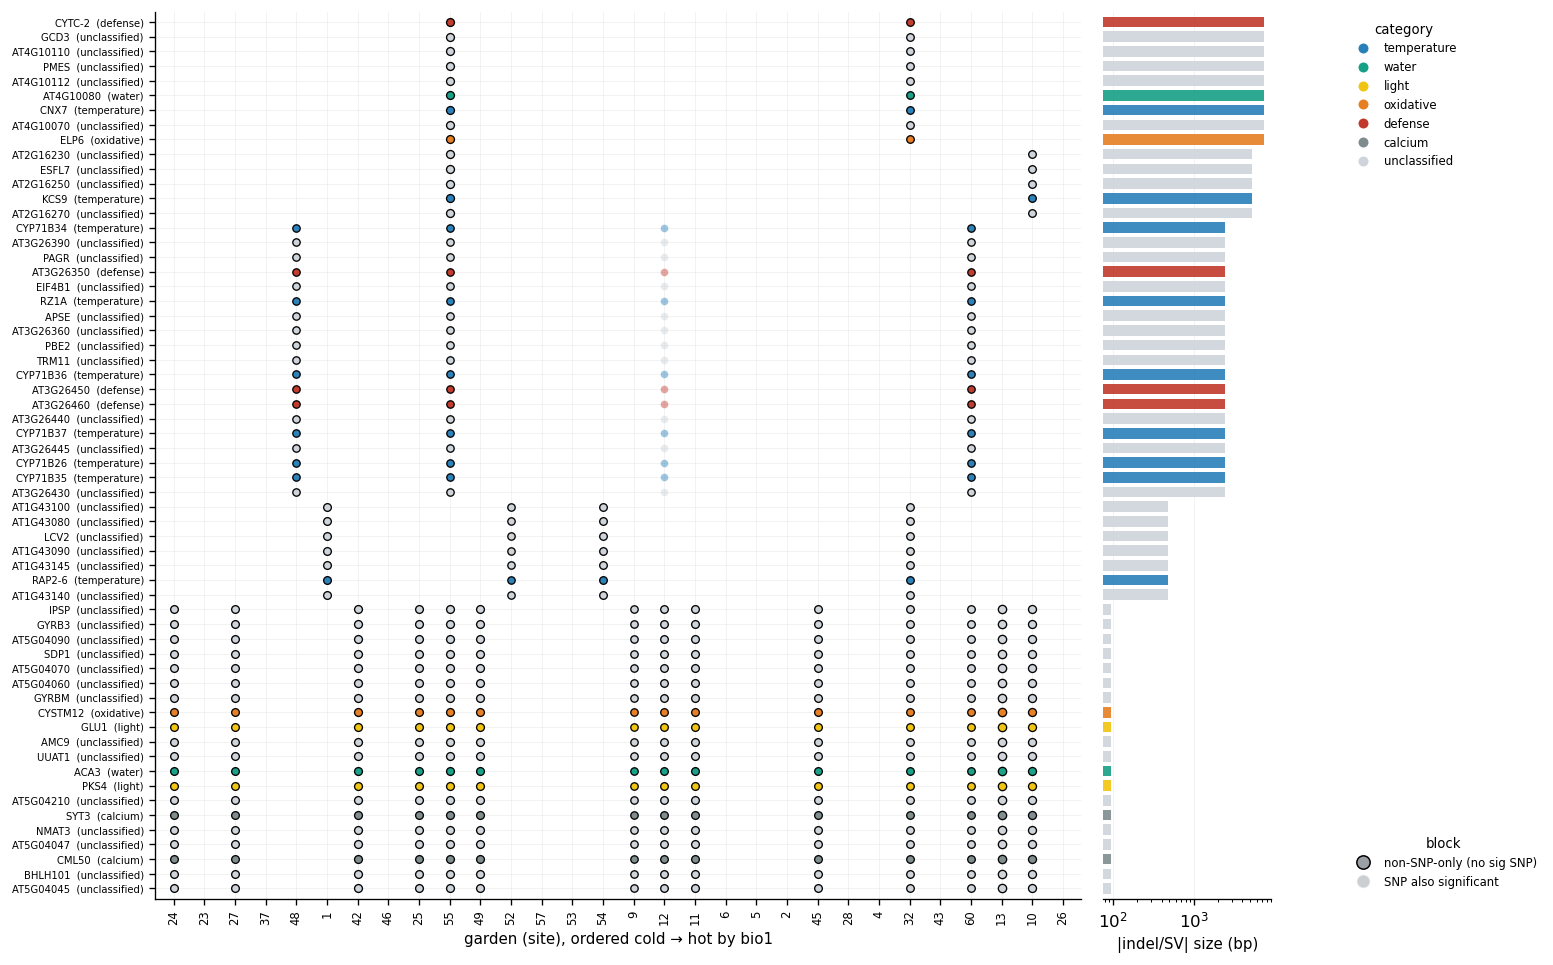

dot grid: 60 genes recurring on >=2 of 30 gardens (all class-Bonferroni blocks; black-edged = non-SNP-only); 292 lower-recurrence genes omitted (present in the CSV).


In [6]:
CATCOL = {"flowering": "#8E44AD", "temperature": "#2980B9", "water": "#16A085",
          "light": "#F1C40F", "oxidative": "#E67E22", "defense": "#C0392B",
          "calcium": "#7F8C8D", "unclassified": "#CED4DA"}
def pcat(g):
    c = [x for x in (rep.loc[g, "categories"] or "").split(",") if x]
    return c[0] if c else "unclassified"

# keep genes recurring on >= thr gardens; raise thr until the figure is <= ~110 rows
thr = 1
while int((rep["n_sites"] >= thr).sum()) > 110 and thr < 25:
    thr += 1
keep = rep.index[rep["n_sites"] >= thr]
gord = rep.loc[keep].sort_values(["size", "n_sites"]).index.tolist()   # small at bottom, large at top
yidx = {g: i for i, g in enumerate(gord)}
D = GA[GA["gene"].isin(keep)].drop_duplicates(["gene", "site"])

H = max(4.0, 0.16 * len(gord))
fig = plt.figure(figsize=(12, H))
gs = fig.add_gridspec(1, 2, width_ratios=[5.5, 1.0], wspace=0.04)
ax = fig.add_subplot(gs[0]); axr = fig.add_subplot(gs[1], sharey=ax)

for _, rr in D.iterrows():
    only = not rr["snp_sig"]
    ax.scatter(xpos[rr["site"]], yidx[rr["gene"]], s=10 + rr["nlp"] * 2.0,
               c=CATCOL.get(pcat(rr["gene"]), "#CED4DA"),
               edgecolors=("black" if only else "white"),
               linewidths=(0.8 if only else 0.3),
               alpha=(0.98 if only else 0.45), zorder=(4 if only else 3))
ax.set_xticks(range(len(site_order)))
ax.set_xticklabels([str(s) for s in site_order], rotation=90, fontsize=7)
ax.set_yticks(range(len(gord)))
ax.set_yticklabels([f"{(rep.loc[g, 'symbol'] or g)}  ({pcat(g)})" for g in gord], fontsize=6)
ax.set_xlim(-0.6, len(site_order) - 0.4); ax.set_ylim(-0.7, len(gord) - 0.3)
ax.grid(True, lw=0.3, c="0.9", zorder=0); ax.set_axisbelow(True)
ax.set_xlabel("garden (site), ordered cold → hot by bio1", fontsize=9)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# right panel: |indel/SV| size (bp), log x, coloured by category (rows are ordered by this)
sizes = [max(int(rep.loc[g, "size"]), 1) for g in gord]                   # floor 1 for log scale
axr.barh(range(len(gord)), sizes, height=0.72,
         color=[CATCOL.get(pcat(g), "#CED4DA") for g in gord], alpha=0.9, zorder=3)
axr.set_xscale("log")
axr.set_xlabel("|indel/SV| size (bp)", fontsize=9)
axr.grid(True, axis="x", lw=0.3, c="0.9", zorder=0); axr.set_axisbelow(True)
plt.setp(axr.get_yticklabels(), visible=False)
for sp in ["top", "right", "left"]:
    axr.spines[sp].set_visible(False)
axr.tick_params(axis="y", length=0)

_present = [c for c in CATCOL if c in {pcat(g) for g in gord}]
_h = [mlines.Line2D([], [], marker="o", ls="", ms=7, mfc=CATCOL[c], mec="white", label=c)
      for c in _present]
leg1 = ax.legend(handles=_h, title="category", loc="upper left", bbox_to_anchor=(1.28, 1.0),
                 frameon=False, fontsize=7, title_fontsize=8)
ax.add_artist(leg1)
_hm = [mlines.Line2D([], [], marker="o", ls="", ms=8, mfc="#9AA0A6", mec="black", mew=0.9,
                     label="non-SNP-only (no sig SNP)"),
       mlines.Line2D([], [], marker="o", ls="", ms=8, mfc="#9AA0A6", mec="white", mew=0.9,
                     alpha=0.5, label="SNP also significant")]
ax.legend(handles=_hm, title="block", loc="lower left", bbox_to_anchor=(1.28, 0.0),
          frameon=False, fontsize=7, title_fontsize=8)
fig.tight_layout(); plt.show()
print(f"dot grid: {len(gord)} genes recurring on >={thr} of {len(sites)} gardens "
      f"(all class-Bonferroni blocks; black-edged = non-SNP-only); "
      f"{rep.shape[0] - len(gord)} lower-recurrence genes omitted (present in the CSV).")

## 2. Per-garden mirror Manhattan — SNPs are low where the SV-only peak is

For the gardens carrying the most non-SNP-only peaks: SNP −log10p **up**, sv **down**, shared
genome axis. Grey dashed verticals mark that garden's non-SNP-only Bonferroni blocks (gene-labelled);
the SNP (up) side is low there. Dashed horizontals = per-class block-level Bonferroni.

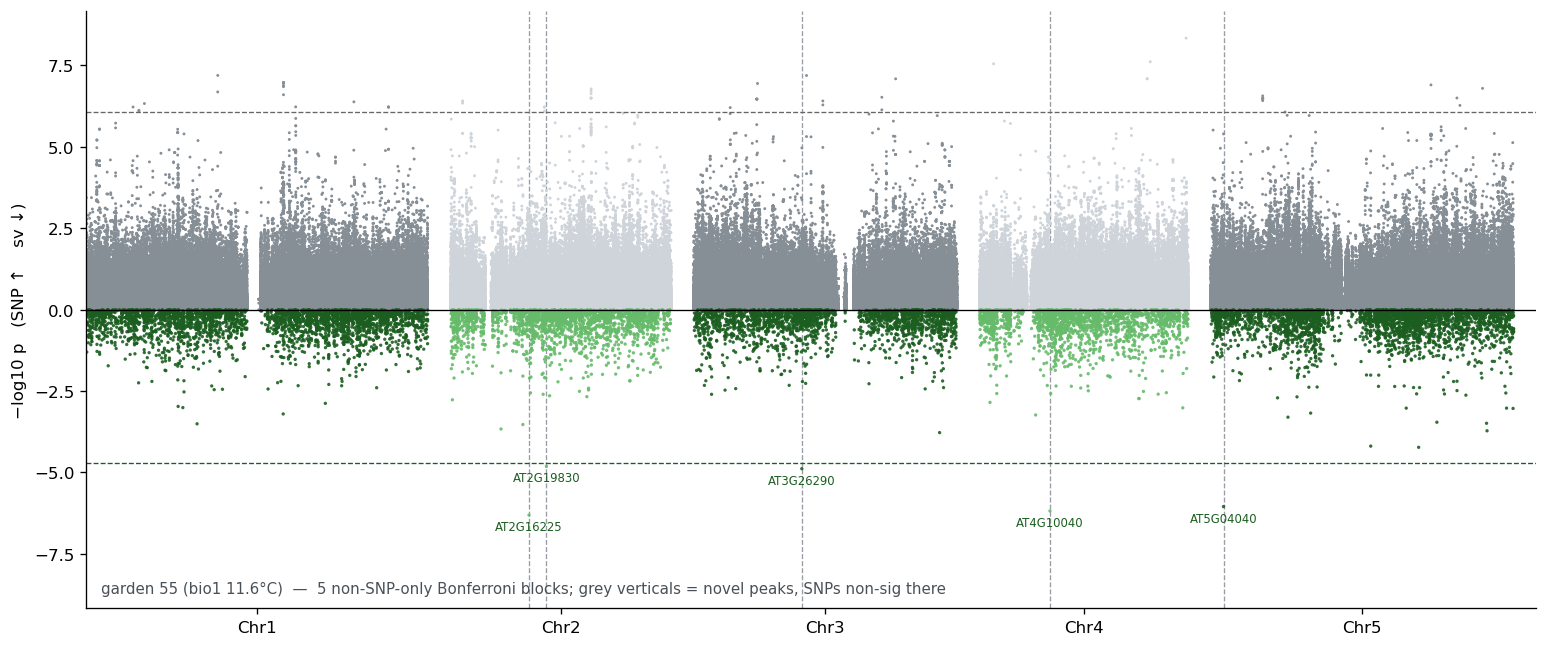

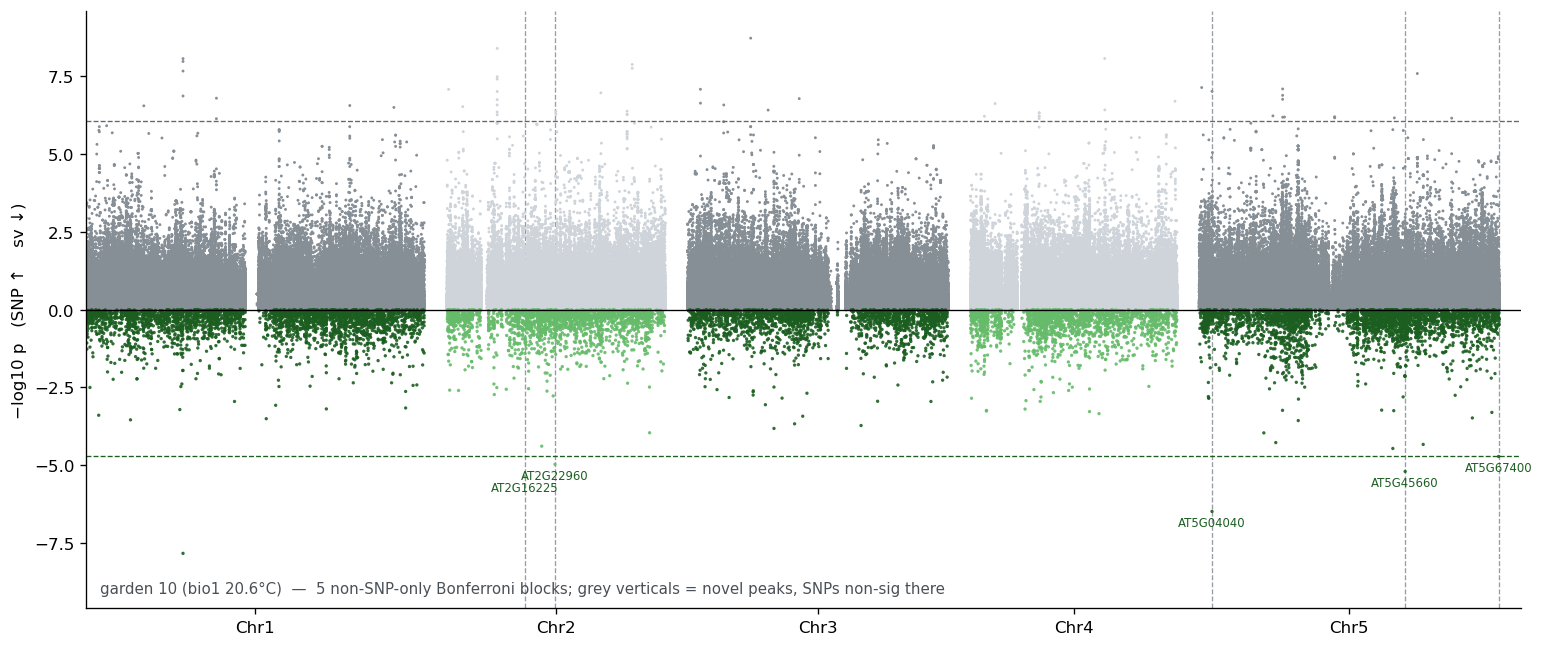

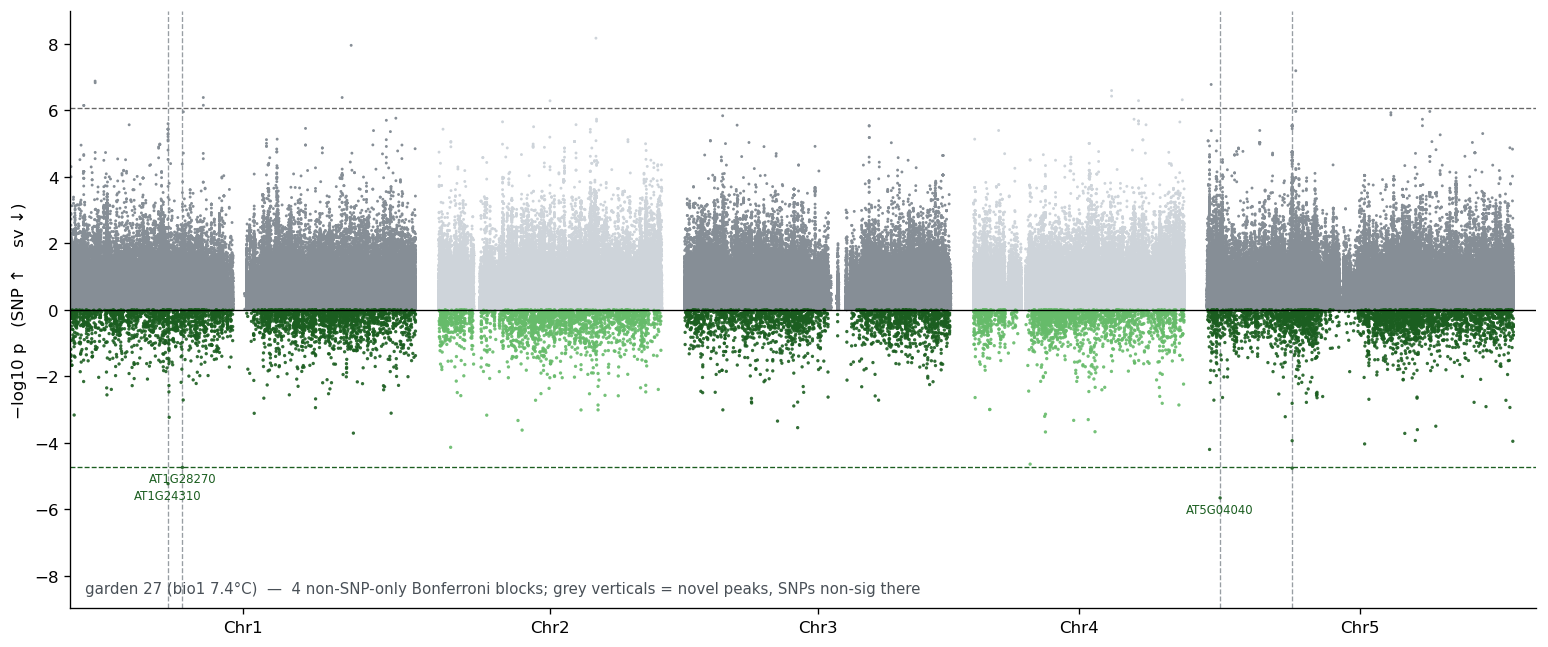

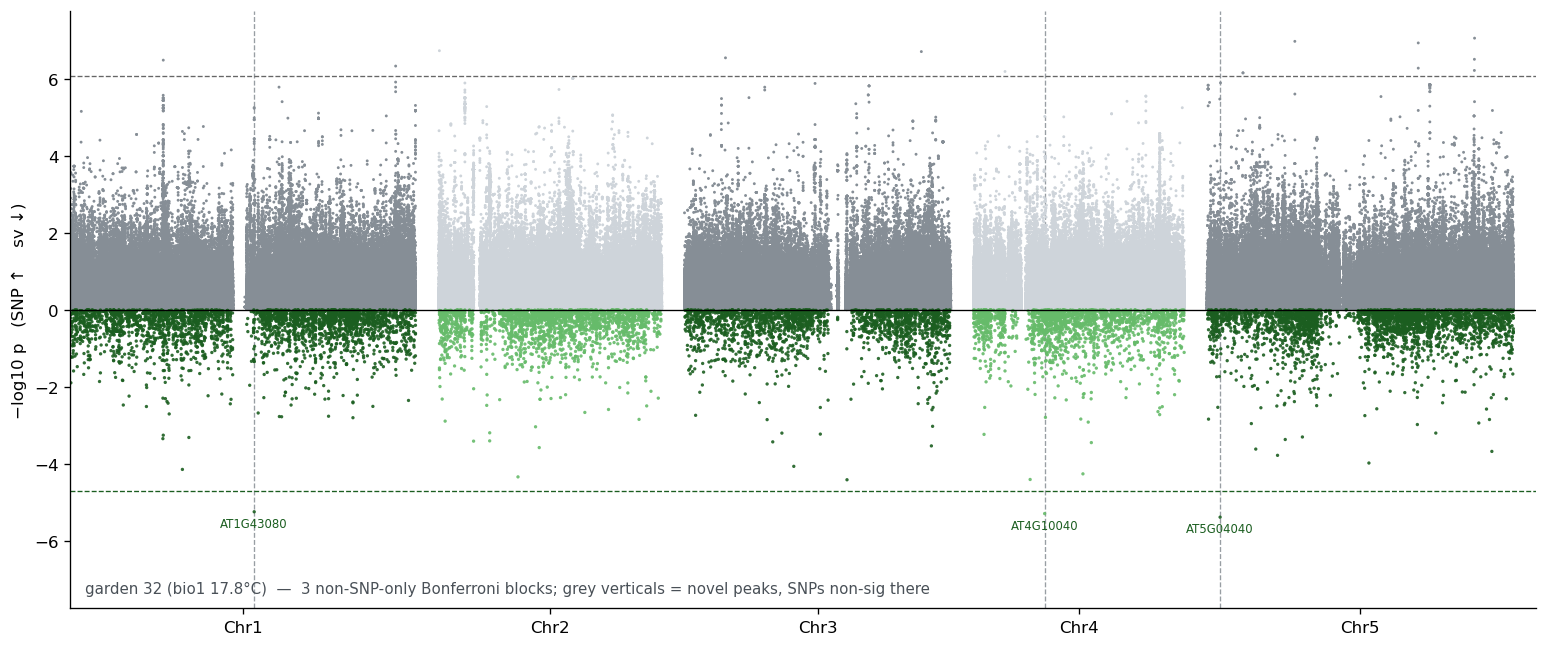

In [7]:
# genome x-coordinate
chrom_len = {c: int(SNP["pos"][SNP["chrom"] == c].max()) for c in CHROM_ORDER}
off, cum = {}, 0
for c in CHROM_ORDER:
    off[c] = cum; cum += chrom_len[c] + int(2e6)
ticks = [off[c] + chrom_len[c] / 2 for c in CHROM_ORDER]
def gx(chrom, pos): return np.array([off[c] for c in chrom]) + np.asarray(pos)
SNP_GREY = {"Chr1": "#868E96", "Chr2": "#CED4DA", "Chr3": "#868E96", "Chr4": "#CED4DA", "Chr5": "#868E96"}
CL_GREEN = {"Chr1": "#1B5E20", "Chr2": "#66BB6A", "Chr3": "#1B5E20", "Chr4": "#66BB6A", "Chr5": "#1B5E20"}
GREEN_DK = "#1B5E20"
nblk = {"snp": len(set(SNP["blk"]) - {""}), CLS: len(set(CL["blk"]) - {""})}
BONF = {k: -np.log10(0.05 / v) for k, v in nblk.items()}

# gene label for a block = first overlapping gene
blk_gene = {b: (genes_on(b)[:1] or [""])[0] for b in ALLPK.block.unique()}
def gname(gid):
    if not gid: return ""
    nm = GENES.loc[GENES.gene == gid, "name"]
    return nm.iloc[0] if len(nm) and isinstance(nm.iloc[0], str) and nm.iloc[0] else gid

top_gardens = (ALLPK[~ALLPK.snp_sig].groupby("site")["block"].nunique()
               .sort_values(ascending=False).head(4).index.tolist())
for g in top_gardens:
    si = sites.index(g)
    pk = ALLPK[(ALLPK.site == g) & (~ALLPK.snp_sig)].copy()          # non-SNP-only blocks this garden
    pk = pk.sort_values("nlp", ascending=False).drop_duplicates("block")
    pk["gx"] = gx(pk.chrom.values, pk.pos.values)
    snl, cnl = nlp(SNP, si), nlp(CL, si)
    sgx, cgx = gx(SNP["chrom"], SNP["pos"]), gx(CL["chrom"], CL["pos"])
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for _, r in pk.iterrows():
        ax.axvline(r.gx, color="#6c757d", lw=0.8, ls="--", alpha=0.7, zorder=0)
    ax.scatter(sgx, snl, s=3, c=[SNP_GREY[c] for c in SNP["chrom"]], rasterized=True, linewidths=0, zorder=2)
    ax.scatter(cgx, -cnl, s=4, c=[CL_GREEN[c] for c in CL["chrom"]], rasterized=True, linewidths=0, alpha=0.9, zorder=2)
    ax.axhline(BONF["snp"], ls="--", lw=.8, c="0.4"); ax.axhline(-BONF[CLS], ls="--", lw=.8, c=GREEN_DK)
    ax.axhline(0, lw=.8, c="k")
    for _, r in pk.iterrows():
        ax.annotate(gname(blk_gene.get(r.block, "")), (r.gx, -r.nlp), fontsize=7, ha="center", va="top",
                    xytext=(0, -3), textcoords="offset points", color=GREEN_DK, zorder=5)
    ax.set_xticks(ticks); ax.set_xticklabels(CHROM_ORDER)
    ax.set_ylabel(f"−log10 p   (SNP ↑    {CLS} ↓)")
    yl = max(snl.max(), cnl.max()) * 1.1; ax.set_xlim(0, cum); ax.set_ylim(-yl, yl)
    ax.annotate(f"garden {g} (bio1 {site_bio1[g]:.1f}°C)  —  {len(pk)} non-SNP-only Bonferroni blocks; "
                f"grey verticals = novel peaks, SNPs non-sig there",
                (0.01, 0.02), xycoords="axes fraction", fontsize=9, color="#495057", va="bottom")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    fig.tight_layout(); plt.show()

## 3. Zoom loci — the strongest recurrent SV-only peaks

Top recurrent non-SNP-only SV-only peaks in their strongest garden: ±60 kb window, SNP (grey) vs
sv (green) −log10p, gene models underneath, the sv lead ringed. SNPs flat, sv spiking.

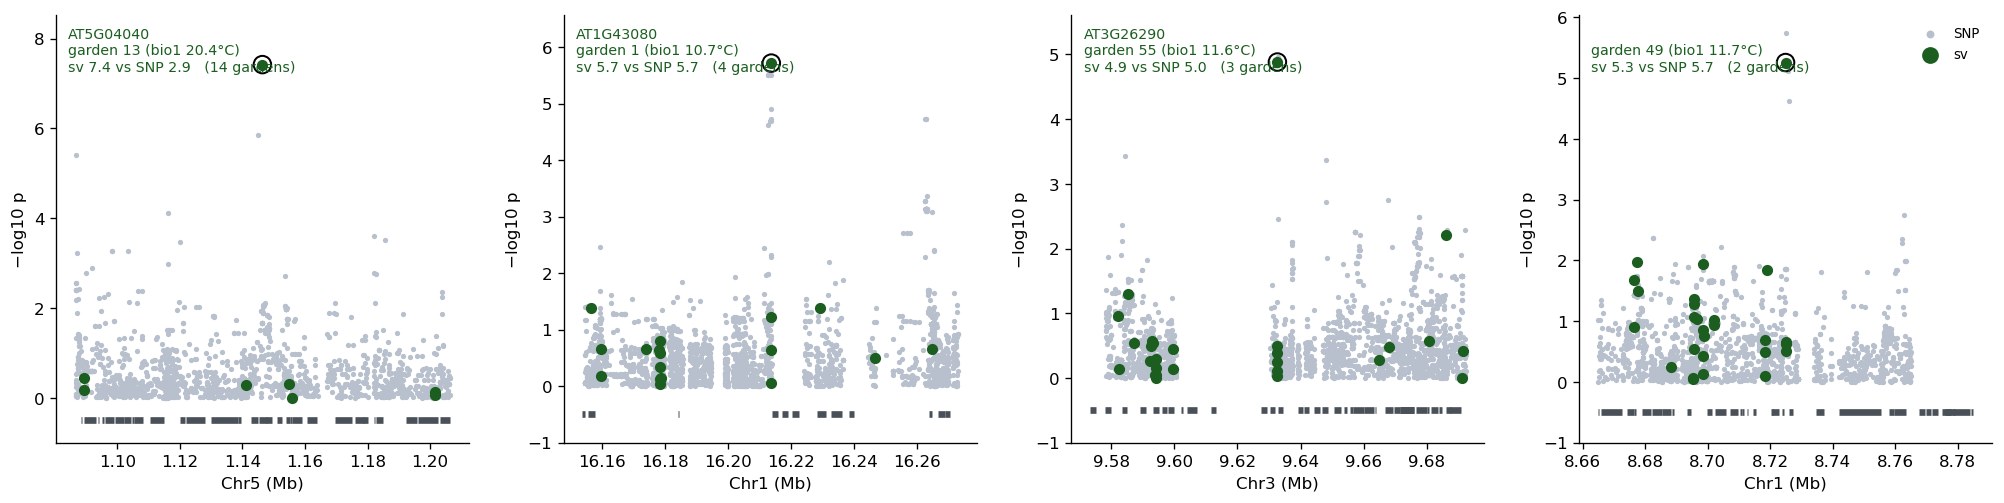

In [8]:
nov = ALLPK[~ALLPK.snp_sig].copy()
top = (nov.groupby("block").agg(chrom=("chrom", "first"), n=("site", "nunique"))
       .sort_values("n", ascending=False).head(4).reset_index())
if len(top):
    fig, axes = plt.subplots(1, len(top), figsize=(4.2 * len(top), 4.3), squeeze=False); axes = axes[0]
    PAD = 60_000
    for ax, (_, b) in zip(axes, top.iterrows()):
        best = nov[nov.block == b.block].sort_values("nlp", ascending=False).iloc[0]
        si = sites.index(int(best.site)); c = b.chrom; center = int(best.pos); lo, hi = center - PAD, center + PAD
        for Dd, col, sz, z, lab in [(SNP, "#B7C0CC", 10, 1, "SNP"), (CL, "#1B5E20", 45, 3, CLS)]:
            w = (Dd["chrom"] == c) & (Dd["pos"] >= lo) & (Dd["pos"] <= hi)
            ax.scatter(Dd["pos"][w] / 1e6, nlp(Dd, si)[w], s=sz, c=col, linewidths=0, zorder=z, label=lab)
        ax.scatter([center / 1e6], [best.nlp], s=110, facecolors="none", edgecolors="k", linewidths=1.2, zorder=4)
        for _, gg in GENES[(GENES.chrom == c) & (GENES.start <= hi) & (GENES.end >= lo)].iterrows():
            ax.plot([max(gg.start, lo) / 1e6, min(gg.end, hi) / 1e6], [-0.5, -0.5], lw=4, c="#495057", solid_capstyle="butt")
        gid = (genes_on(b.block)[:1] or [""])[0]
        ax.annotate(f"{gname(gid)}\ngarden {int(best.site)} (bio1 {site_bio1[int(best.site)]:.1f}°C)\n"
                    f"{CLS} {best.nlp:.1f} vs SNP {best.snp_nlp:.1f}   ({int(b.n)} gardens)",
                    (0.03, 0.97), xycoords="axes fraction", ha="left", va="top", fontsize=8.5, color="#1B5E20", zorder=5)
        ax.set_xlabel(f"{c} (Mb)"); ax.set_ylabel("−log10 p"); ax.set_ylim(-1, max(best.nlp, 3) * 1.15)
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)
    axes[-1].legend(loc="upper right", frameon=False, markerscale=1.5, fontsize=8)
    fig.tight_layout(); plt.show()
else:
    print("no non-SNP-only peaks to zoom")

## Takeaway

On the production **tiling** partition (full coverage), at the **per-garden** level SV-only genuinely
brings peaks the SNP scan misses — Bonferroni-level and **recurrent across independent gardens** (not
FDR noise). Invisible to the aggregate SNP story because garden-specific (local) — consistent with
the polygenic/passenger result at the meta level. The grid keeps SNP-tagged peaks in view (faded) so
novel-vs-redundant is visible per cell, not pre-filtered. Categories from the TAIR/UniProt annotator.
**Caveat:** for the sparse SV class the tiling `merge_small_blocks` can chain empty blocks and enlarge
a block's footprint, so an SV block's *gene* label may include distant unlinked genes — verify a
headline SV locus with founder r² before trusting the attribution (see the SV block-merge note).